<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Semana1/Vis%C3%A3o_Computacional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CÉLULA 1: Importação de Bibliotecas
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

print("Bibliotecas importadas com sucesso! Nossa caixa de ferramentas está pronta.")

# ---


Bibliotecas importadas com sucesso! Nossa caixa de ferramentas está pronta.


Baixando imagem de exemplo...


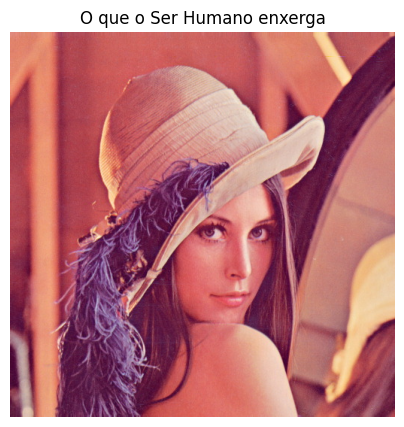

In [ ]:

# CÉLULA 2: Como o computador enxerga uma imagem?
print("Baixando imagem de exemplo...")
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
urllib.request.urlretrieve(url, "imagem_teste.jpg")

# Carregando a imagem
imagem = cv2.imread("imagem_teste.jpg")
# O OpenCV lê em BGR, precisamos converter para RGB para mostrar corretamente na tela
imagem_rgb = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

# Exibindo a imagem para os alunos
plt.figure(figsize=(5,5))
plt.imshow(imagem_rgb)
plt.title("O que o Ser Humano enxerga")
plt.axis('off')
plt.show()

# ---


In [ ]:
# CÉLULA 3: O Segredo da Visão Computacional (A Matriz)
print("\nO que o Computador enxerga (Matriz de Pixels):")
print(f"Formato da imagem: {imagem.shape} -> (Altura, Largura, Canais de Cor RGB)")
print("\nVeja um pedacinho da imagem em números (uma grade de 3x3 pixels no canto da foto):")
print(imagem[0:3, 0:3])

# ---



O que o Computador enxerga (Matriz de Pixels):
Formato da imagem: (512, 512, 3) -> (Altura, Largura, Canais de Cor RGB)

Veja um pedacinho da imagem em números (uma grade de 3x3 pixels no canto da foto):
[[[128 138 225]
  [127 137 224]
  [126 136 224]]

 [[127 137 224]
  [127 137 224]
  [127 137 224]]

 [[127 137 224]
  [127 137 224]
  [128 138 225]]]


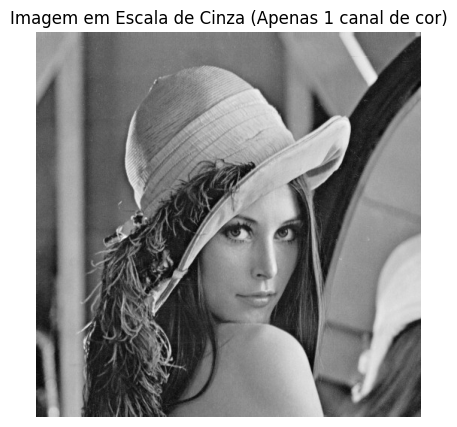


Novo formato da imagem: (512, 512) -> Note que o '3' dos canais de cor sumiu!


In [ ]:
# CÉLULA 4: Pré-processamento (Preparando os Dados)
# Algoritmos de detecção costumam ser mais eficientes em Preto e Branco (escala de cinza)
imagem_cinza = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(5,5))
plt.imshow(imagem_cinza, cmap='gray')
plt.title("Imagem em Escala de Cinza (Apenas 1 canal de cor)")
plt.axis('off')
plt.show()

print(f"\nNovo formato da imagem: {imagem_cinza.shape} -> Note que o '3' dos canais de cor sumiu!")

# ---

In [ ]:
# CÉLULA 5: A Inteligência Artificial em Ação (Detecção)
# Carregando um modelo clássico pré-treinado do OpenCV capaz de achar padrões de rostos
modelo_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# A IA varre a matriz de números procurando o padrão matemático de um rosto
rostos = modelo_cascade.detectMultiScale(imagem_cinza, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

print(f"IA processando... Encontrado(s) {len(rostos)} rosto(s)!")

# ---

IA processando... Encontrado(s) 1 rosto(s)!


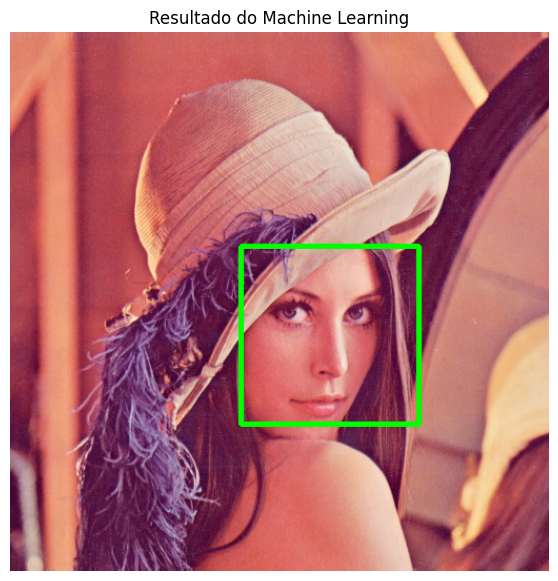

In [ ]:

# CÉLULA 6: Desenhando o resultado e exibindo
imagem_resultado = imagem_rgb.copy()

# Para cada rosto encontrado, desenhamos um retângulo verde
for (x, y, largura, altura) in rostos:
    # (Imagem, ponto_inicial, ponto_final, cor(R,G,B), espessura)
    cv2.rectangle(imagem_resultado, (x, y), (x + largura, y + altura), (0, 255, 0), 3)

plt.figure(figsize=(7,7))
plt.imshow(imagem_resultado)
plt.title("Resultado do Machine Learning")
plt.axis('off')
plt.show()